In [1]:
!uv pip list

Using Python 3.12.3 environment at: /home/mnt/zwx/ptyro_env
Package                   Version        Editable project location
------------------------- -------------- -------------------------
absl-py                   2.3.1
anyio                     4.10.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.3.0
asttokens                 3.0.0
async-lru                 2.0.5
attrs                     25.3.0
babel                     2.17.0
beartype                  0.21.0
beautifulsoup4            4.13.4
black                     25.1.0
bleach                    6.2.0
certifi                   2025.8.3
cffi                      1.17.1
charset-normalizer        3.4.2
chex                      0.1.90
click                     8.2.1
comm                      0.2.3
contourpy                 1.3.3
cryptography              45.0.6
cycler                    0.12.1
debugpy                   1.8.16
decorator                 5.2.1
defusedxml            

In [2]:
%cd /home/mnt/zwx/ptyrodactyl/cbed_sim_workflow/
%load_ext autoreload
%autoreload 2

/home/mnt/zwx/ptyrodactyl/cbed_sim_workflow


In [3]:
import cv2

In [5]:
from cbed_simulation import contrast_stretch, atomic_potential, parse_xyz, overall_wrapper
from jax import numpy as jnp
import matplotlib.pyplot as plt

In [6]:
import itertools
all_possible_zones = [[0,0,1],
                      [0,1,1],
                      [1,1,1],
                      [0,1,2],
                      [1,1,2],
                      [0,1,3],
                      [0,2,3],
                      [1,1,3],
                      [1,2,3],
                      [2,2,3]]
#get all possible permutations for each zone axis
all_possible_zones_permutations = []
for zone in all_possible_zones:
    all_possible_zones_permutations += list(set(itertools.permutations(zone)))
print(len(all_possible_zones_permutations))
print(len(set(all_possible_zones_permutations)))

40
40


In [21]:
print(all_possible_zones_permutations)

[(1, 0, 0), (0, 0, 1), (0, 1, 0), (1, 0, 1), (1, 1, 0), (0, 1, 1), (1, 1, 1), (0, 2, 1), (1, 2, 0), (2, 1, 0), (2, 0, 1), (0, 1, 2), (1, 0, 2), (1, 2, 1), (2, 1, 1), (1, 1, 2), (0, 3, 1), (0, 1, 3), (3, 1, 0), (1, 0, 3), (1, 3, 0), (3, 0, 1), (3, 2, 0), (0, 2, 3), (3, 0, 2), (2, 0, 3), (0, 3, 2), (2, 3, 0), (1, 1, 3), (1, 3, 1), (3, 1, 1), (1, 3, 2), (1, 2, 3), (2, 1, 3), (3, 2, 1), (3, 1, 2), (2, 3, 1), (2, 2, 3), (2, 3, 2), (3, 2, 2)]


In [5]:
a = jnp.array([[0, 0, 0], [1, 0, 0], [0, 1, 0]])
a

Array([[0, 0, 0],
       [1, 0, 0],
       [0, 1, 0]], dtype=int64)

In [5]:
!tar -xvzf /home/mnt/New_Bi2Se3_layered.tar.gz -C /home/mnt/New_Bi2Se3_layered/

tar: /home/mnt/New_Bi2Se3_layered: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now


/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [15]:
import glob
structures_path = '/home/mnt/zwx/WSe2_Chiral/chrial.xyz'


In [8]:
import numpy as np
pixel_size = 0.1 #Angstroms
element_IDS = list(range(0, 103))
kirkland_potentials = {}
for element_ID in element_IDS:
    potential = atomic_potential(
        atom_no=int(element_ID),
        pixel_size=pixel_size,
        sampling=16,
        potential_extent=4,
        datafile="/home/mnt/zwx/Kirkland_Potentials.npy",
    )
    kirkland_potentials[int(element_ID)] = potential


kirkland_jax = jnp.asarray([kirkland_potentials[int(el)] for el in element_IDS])
#for ei, element_ID in enumerate(element_IDS):
    #atoms[atoms[:,0] == element_ID, 0] = ei

finalsize [80 80]
sspot.shape (1280, 1280)
finalsize [80 80]
sspot.shape (1280, 1280)
finalsize [80 80]
sspot.shape (1280, 1280)
finalsize [80 80]
sspot.shape (1280, 1280)
finalsize [80 80]
sspot.shape (1280, 1280)
finalsize [80 80]
sspot.shape (1280, 1280)
finalsize [80 80]
sspot.shape (1280, 1280)


KeyboardInterrupt: 

In [ ]:

with open(kirkland_jax_cache, 'wb') as f:
    pickle.dump(kirkland_jax, f)

In [9]:
import pickle
kirkland_jax_cache = '/home/mnt/zwx/ptyrodactyl/cbed_sim_workflow/kirkland_jax_cached.pkl'
with open(kirkland_jax_cache, 'rb') as f:
    kirkland_jax= pickle.load(f)

In [10]:
import json
with open('atom_numbers.json', 'r') as f:
    atom_numbers = json.load(f)

In [1]:
all_structures

NameError: name 'all_structures' is not defined

In [67]:
from cbed_simulation import overall_wrapper_rotate_first
all_cbed_patterns = []
all_test_coords = []
for structure in [structures_path]:
    atoms, metadata, element = parse_xyz(f'{structure}', element_specified=True)
    atoms[:,0] = atoms[:,0] - 1
    poss = jnp.array([[0,0]])
    # 2.5 mrad semiangle at 100 kV has a probe diameter of about 2 nm
    for zone in all_possible_zones_permutations[:6]:
        cbed_patterns_2, slices_2, test_rotated_coords_2, test_rotated_cells_2 = overall_wrapper_rotate_first(atoms, metadata, zone_hkl = jnp.array(zone), theta = 0, pixel_size = 0.1, kirkland_jax=kirkland_jax
                                                                                    , poss = poss, threshold_A = 40, perturbation = 0.0, max_slices=50, probe_radius_mrad = 1.0)
        #cbed_patterns, slices, test_rotated_coords, test_rotated_cells = overall_wrapper(atoms, metadata, zone_hkl = jnp.array([1,1,3]), theta = jnp.pi/4, pixel_size = 0.1, kirkland_jax=kirkland_jax
        #                                                                                , poss = poss, threshold_A = 80 )
        all_cbed_patterns.append(cbed_patterns_2)
        all_test_coords.append(test_rotated_coords_2)

Time taken for preprocessing: 10.676992893218994 seconds
time taken for cbed calculation: 3.0522031784057617 seconds
Time taken for preprocessing: 10.6580810546875 seconds
time taken for cbed calculation: 1.6840500831604004 seconds
Time taken for preprocessing: 10.819727182388306 seconds
time taken for cbed calculation: 2.0887866020202637 seconds
Time taken for preprocessing: 11.849273681640625 seconds
time taken for cbed calculation: 3.7881412506103516 seconds
Time taken for preprocessing: 16.397645235061646 seconds
time taken for cbed calculation: 10.299135684967041 seconds
Time taken for preprocessing: 11.900352954864502 seconds
time taken for cbed calculation: 3.7748730182647705 seconds


In [19]:
len(slices_2)

111

In [10]:
print(cbed_patterns.data_array.shape, cbed_patterns.calib_x, cbed_patterns.calib_y)
print(cbed_patterns_2.data_array.shape, cbed_patterns_2.calib_x, cbed_patterns_2.calib_y)

(1, 1846, 1847) [0.00541712] [0.00541712]
(1, 656, 657) [0.0152439] [0.0152439]


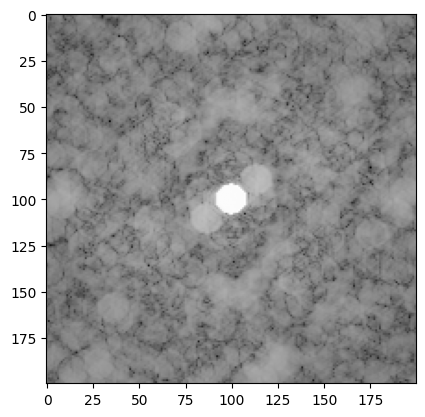

In [19]:

fig = plt.figure()
data = jnp.log10(cbed_patterns_2.data_array)
data_center = data.shape[-1] // 2
plt.imshow(data[0,data_center-100:data_center+100, data_center-100:data_center+100], cmap='gray')

In [18]:
fig = plt.figure()
data = cbed_patterns.data_array
calibration_length = 2.5 #A-1
calibration_length_pixels = int(calibration_length / cbed_patterns.calib_x[0])

data_center = data.shape[-1] // 2
plt.imshow(data[0,data_center-calibration_length_pixels//2:data_center+calibration_length_pixels//2, data_center-calibration_length_pixels//2:data_center+calibration_length_pixels//2], vmin=0, vmax=0.01, cmap='gray')

calibration_length = 2.5 #A-1
calibration_length_pixels = int(calibration_length / cbed_patterns_2.calib_x[0])
fig = plt.figure()
data = cbed_patterns_2.data_array
data_center = data.shape[-1] // 2
plt.imshow(data[0,data_center-calibration_length_pixels//2:data_center+calibration_length_pixels//2, data_center-calibration_length_pixels//2:data_center+calibration_length_pixels//2], vmin=0, vmax=0.01, cmap='gray')

NameError: name 'cbed_patterns' is not defined

<Figure size 640x480 with 0 Axes>

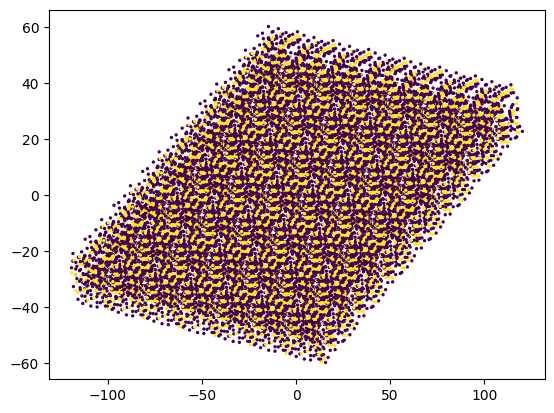

In [20]:

fig = plt.figure()
plt.scatter(test_rotated_coords_2[:,1], test_rotated_coords_2[:,2], s=2, c=test_rotated_coords_2[:,0])

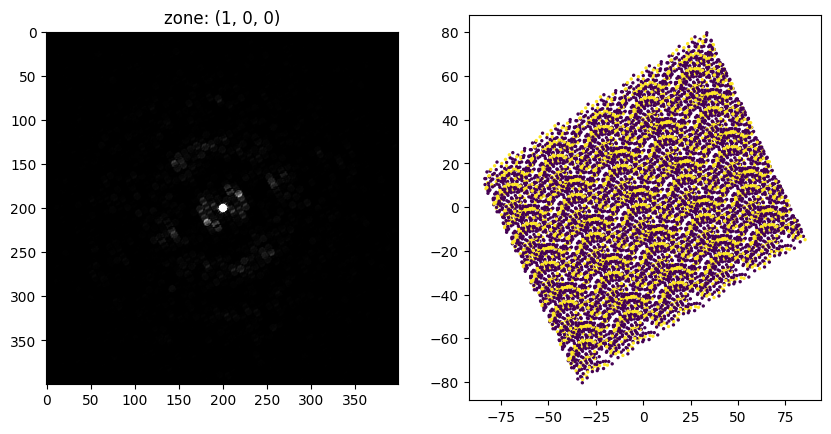

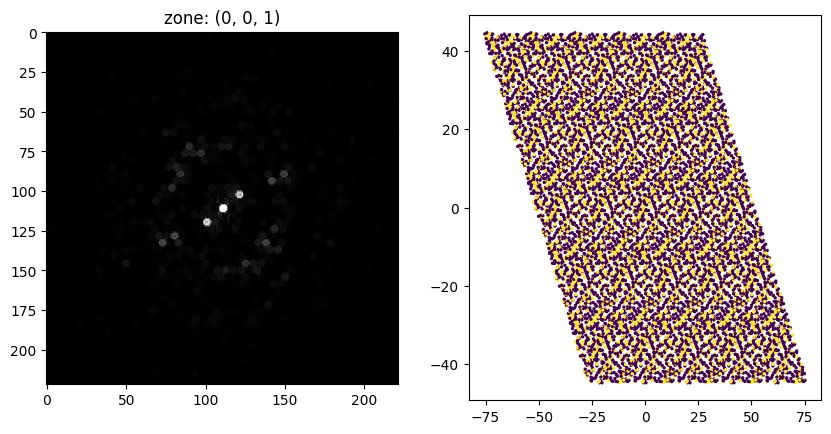

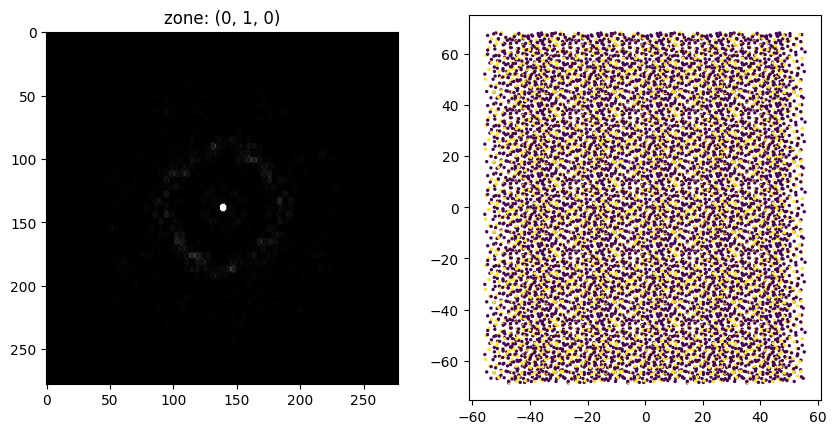

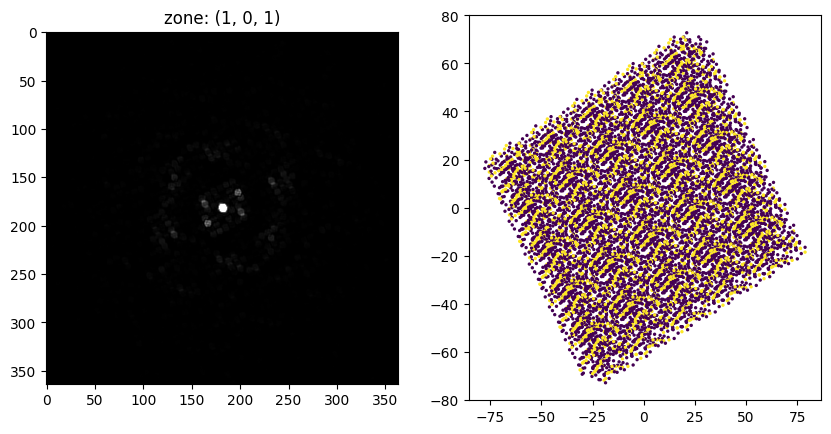

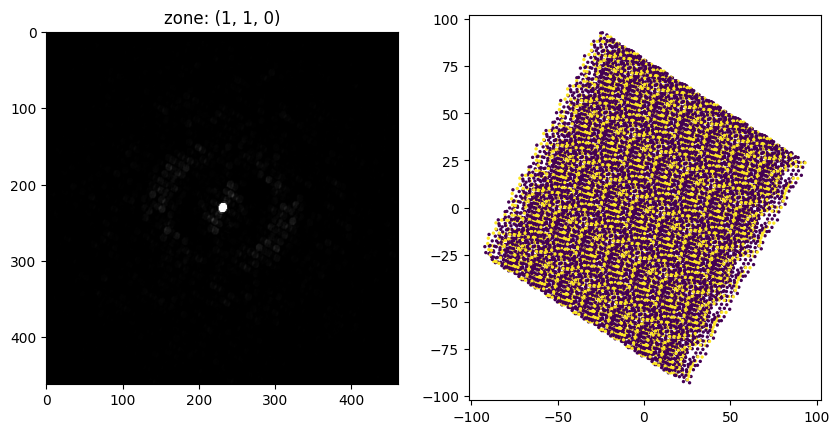

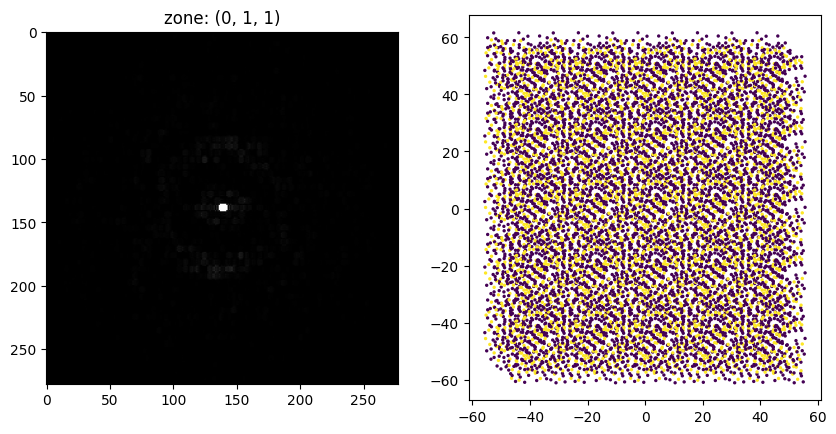

In [70]:
from cbed_simulation import contrast_stretch, atomic_potential, parse_xyz, overall_wrapper
for i, cbed in enumerate(all_cbed_patterns):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    data = cbed.data_array
    calibration_length = 2.5 #A-1
    calibration_length_pixels = int(calibration_length / cbed.calib_x[0])
    data_center = data.shape[-1] // 2
    axs[0].imshow(data[0,data_center-calibration_length_pixels//2:data_center+calibration_length_pixels//2, data_center-calibration_length_pixels//2:data_center+calibration_length_pixels//2], vmin=0, vmax=0.005, cmap='gray')
    axs[0].set_title(f'zone: {all_possible_zones_permutations[i]}')
    axs[1].scatter(all_test_coords[i][:,1], all_test_coords[i][:,2], s=2, c=all_test_coords[i][:,0])
    
    plt.show()

In [62]:
zone = [1,1,0]
all_cbed_patterns_defocus = []
all_test_coords_defocus = []
for defocus in [0, -200, -2000, -20000]:
    
    cbed_patterns_2, slices_2, test_rotated_coords_2, test_rotated_cells_2 = overall_wrapper_rotate_first(atoms, metadata, zone_hkl = jnp.array(zone), theta = 0, pixel_size = 0.1, kirkland_jax=kirkland_jax
                                                                                    , poss = poss, threshold_A = 40, perturbation = 0.0, max_slices=50, defocus=defocus) 
    #cbed_patterns, slices, test_rotated_coords, test_rotated_cells = overall_wrapper(atoms, metadata, zone_hkl = jnp.array([1,1,3]), theta = jnp.pi/4, pixel_size = 0.1, kirkland_jax=kirkland_jax
    #                                                                                , poss = poss, threshold_A = 80 )
    all_cbed_patterns_defocus.append(cbed_patterns_2)
    all_test_coords_defocus.append(test_rotated_coords_2)

Time taken for preprocessing: 17.766146898269653 seconds
time taken for cbed calculation: 10.048810958862305 seconds
Time taken for preprocessing: 16.161948204040527 seconds
time taken for cbed calculation: 10.107860326766968 seconds
Time taken for preprocessing: 17.731795072555542 seconds
time taken for cbed calculation: 10.280744791030884 seconds
Time taken for preprocessing: 18.17354154586792 seconds
time taken for cbed calculation: 10.305384159088135 seconds


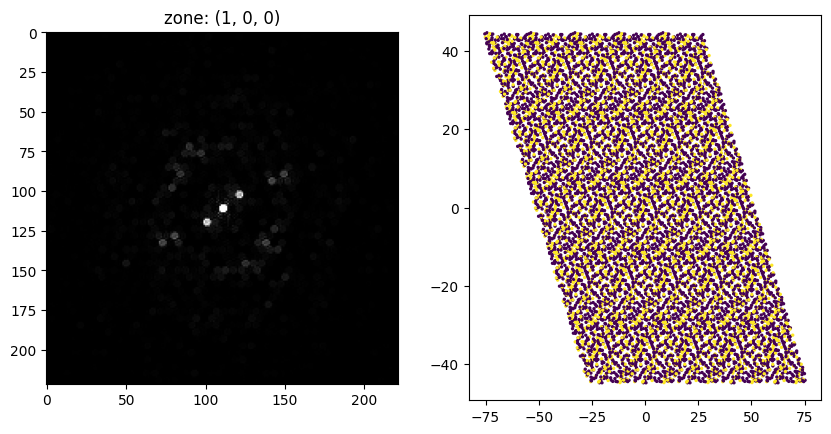

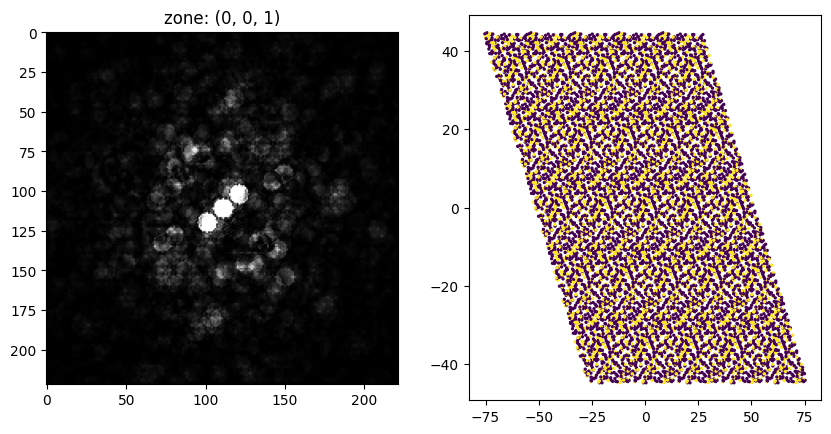

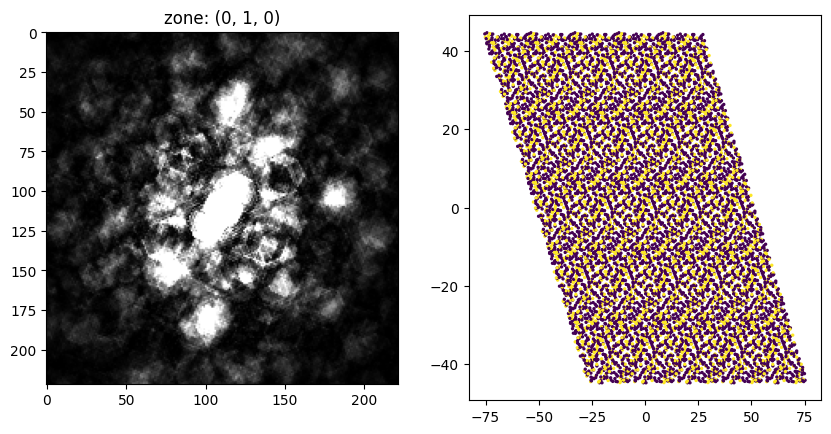

In [66]:
from cbed_simulation import contrast_stretch, atomic_potential, parse_xyz, overall_wrapper
for i, cbed in enumerate(all_cbed_patterns_defocus):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    data = cbed.data_array
    calibration_length = 2.5 #A-1
    calibration_length_pixels = int(calibration_length / cbed.calib_x[0])
    data_center = data.shape[-1] // 2
    axs[0].imshow(data[0,data_center-calibration_length_pixels//2:data_center+calibration_length_pixels//2, data_center-calibration_length_pixels//2:data_center+calibration_length_pixels//2], vmin=0, vmax=0.005, cmap='gray')
    axs[0].set_title(f'zone: {all_possible_zones_permutations[i]}')
    axs[1].scatter(all_test_coords_defocus[i][:,1], all_test_coords_defocus[i][:,2], s=2, c=all_test_coords_defocus[i][:,0])
    
    plt.show()

In [ ]:
for

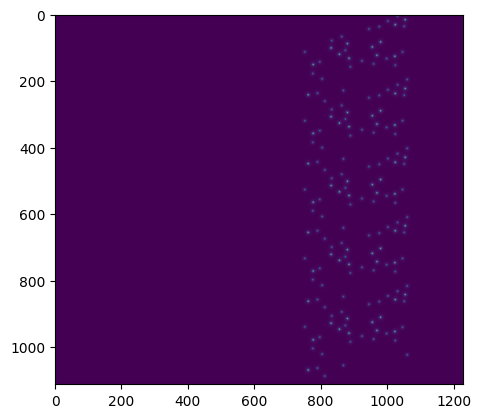

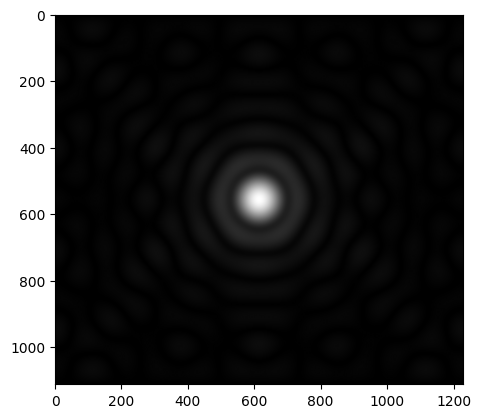

In [61]:
from ptyrodactyl.electrons import stem_4D, cbed, make_probe
probe = make_probe(aperture=2.5,
                   voltage = 100,
                   defocus = -2000.0,
                   image_size = jnp.array(slices_2[0].shape),
                   calibration_pm = pixel_size*100,
                   #defocus = -0.0,
                   #c3=0.0,
                   #c5=0.0

                   )
fig = plt.figure()
plt.imshow(slices_2[25])
fig = plt.figure()
plt.imshow(jnp.abs(probe), cmap='gray')

In [65]:
zone = [0,0,1]
all_cbed_patterns_defocus = []
all_test_coords_defocus = []
for probe_radius_mrad in [1.0, 2.5, 5.0]:
    
    cbed_patterns_2, slices_2, test_rotated_coords_2, test_rotated_cells_2 = overall_wrapper_rotate_first(atoms, metadata, zone_hkl = jnp.array(zone), theta = 0, pixel_size = 0.1, kirkland_jax=kirkland_jax
                                                                                    , poss = poss, threshold_A = 40, perturbation = 0.0, max_slices=50, probe_radius_mrad = probe_radius_mrad) 
    #cbed_patterns, slices, test_rotated_coords, test_rotated_cells = overall_wrapper(atoms, metadata, zone_hkl = jnp.array([1,1,3]), theta = jnp.pi/4, pixel_size = 0.1, kirkland_jax=kirkland_jax
    #                                                                                , poss = poss, threshold_A = 80 )
    all_cbed_patterns_defocus.append(cbed_patterns_2)
    all_test_coords_defocus.append(test_rotated_coords_2)

Time taken for preprocessing: 9.765539407730103 seconds
time taken for cbed calculation: 1.5594689846038818 seconds
Time taken for preprocessing: 10.900011539459229 seconds
time taken for cbed calculation: 1.7737150192260742 seconds
Time taken for preprocessing: 11.040474891662598 seconds
time taken for cbed calculation: 1.68998384475708 seconds


In [ ]:
from cbed_simulation import contrast_stretch, atomic_potential, parse_xyz, overall_wrapper
for i, cbed in enumerate(all_cbed_patterns):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    data = cbed.data_array
    calibration_length = 2.5 #A-1
    calibration_length_pixels = int(calibration_length / cbed.calib_x[0])
    data_center = data.shape[-1] // 2
    axs[0].imshow(data[0,data_center-calibration_length_pixels//2:data_center+calibration_length_pixels//2, data_center-calibration_length_pixels//2:data_center+calibration_length_pixels//2], vmin=0, vmax=0.01, cmap='gray')
    axs[0].set_title(f'zone: {all_possible_zones_permutations[i]}')
    axs[1].scatter(all_test_coords[i][:,1], all_test_coords[i][:,2], s=2, c=all_test_coords[i][:,0])
    
    plt.show()

'/home/mnt/zwx/mp_structures_Bi/BiSe/mp-1182583'

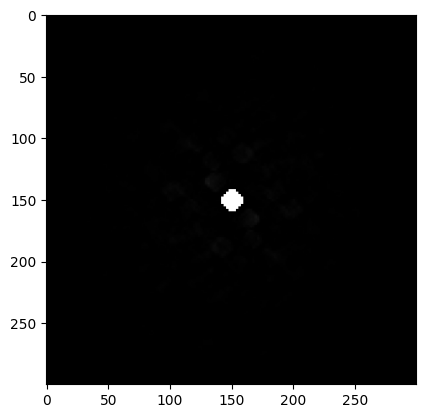

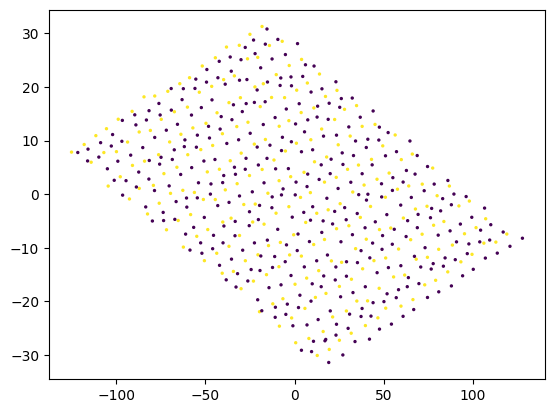

In [6]:
fig = plt.figure()
plt.imshow(cropped_data, cmap='gray', vmin = 0, vmax=0.01)
fig = plt.figure()
plt.scatter(test_rotated_coords_2[:,1], test_rotated_coords_2[:,2], s=2, c=test_rotated_coords_2[:,0])

In [4]:
import h5py
import matplotlib.pyplot as plt
cbeds = []
structure = all_structures[9]
with open(f'{structure}/simulated_cbed_2.5mrad.h5', 'rb') as f:
    with h5py.File(f, 'r') as h5_file:
        for key in h5_file.keys():
            print(f"Key: {key}")
            group = h5_file[key]
            print(f"  Filename: {group.attrs['filename']}")
            print(f"  Zone Axis: {group['zone_axis'][:]}")
            print(f"  Position: {group['position'][:]}")
            print(f"  Rotation: {group.attrs['rotation']}")
            #print(f"  Crop: {group['crop'][:]}")
            print(f"  Scale: {group.attrs['scale']}")
            cbeds.append(group['cbed'][:])
#for cbed in cbeds:
    #fig = plt.figure(figsize=(4,4))
    #plt.imshow(cbed, vmin = 0, vmax = 0.01, cmap='gray')

Key: 2025-09-24 04:26:08_0
  Filename: /home/mnt/zwx/mp_structures_Bi/BiSe/mp-1182583/xyz.xyz
  Zone Axis: [1 0 0]
  Position: [0 0]
  Rotation: 0.15746985816870115
  Scale: 0.008333333333333333
Key: 2025-09-24 04:26:08_1
  Filename: /home/mnt/zwx/mp_structures_Bi/BiSe/mp-1182583/xyz.xyz
  Zone Axis: [1 0 0]
  Position: [0 0]
  Rotation: 2.7327975498092
  Scale: 0.008333333333333333
Key: 2025-09-24 04:26:08_2
  Filename: /home/mnt/zwx/mp_structures_Bi/BiSe/mp-1182583/xyz.xyz
  Zone Axis: [1 0 0]
  Position: [0 0]
  Rotation: 2.0170965377865313
  Scale: 0.008333333333333333
Key: 2025-09-24 04:26:08_3
  Filename: /home/mnt/zwx/mp_structures_Bi/BiSe/mp-1182583/xyz.xyz
  Zone Axis: [1 0 0]
  Position: [0 0]
  Rotation: 1.8893800137124954
  Scale: 0.008333333333333333
Key: 2025-09-24 04:26:08_4
  Filename: /home/mnt/zwx/mp_structures_Bi/BiSe/mp-1182583/xyz.xyz
  Zone Axis: [1 0 0]
  Position: [0 0]
  Rotation: 0.2761414454138881
  Scale: 0.008333333333333333
Key: 2025-09-24 04:26:08_5
  Fil

In [5]:
all_possible_zones_permutations

NameError: name 'all_possible_zones_permutations' is not defined

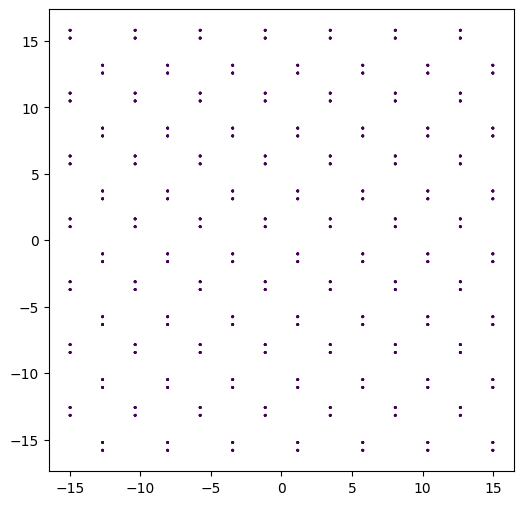

In [69]:
fig = plt.figure(figsize=(6,6))
plt.scatter(test_rotated_coords[:,1], test_rotated_coords[:,2], c = test_rotated_coords[:,0], s=1)

Time taken for preprocessing: 10.304492473602295 seconds
time taken for cbed calculation: 2.3686013221740723 seconds
Time taken for preprocessing: 10.72723126411438 seconds
time taken for cbed calculation: 2.4641005992889404 seconds
Time taken for preprocessing: 10.363645315170288 seconds
time taken for cbed calculation: 1.3818302154541016 seconds
Time taken for preprocessing: 10.695350408554077 seconds
time taken for cbed calculation: 2.0380070209503174 seconds
Time taken for preprocessing: 10.664973497390747 seconds
time taken for cbed calculation: 1.4426155090332031 seconds
Time taken for preprocessing: 10.678945302963257 seconds
time taken for cbed calculation: 2.029303550720215 seconds
Time taken for preprocessing: 10.371489524841309 seconds
time taken for cbed calculation: 1.4683616161346436 seconds


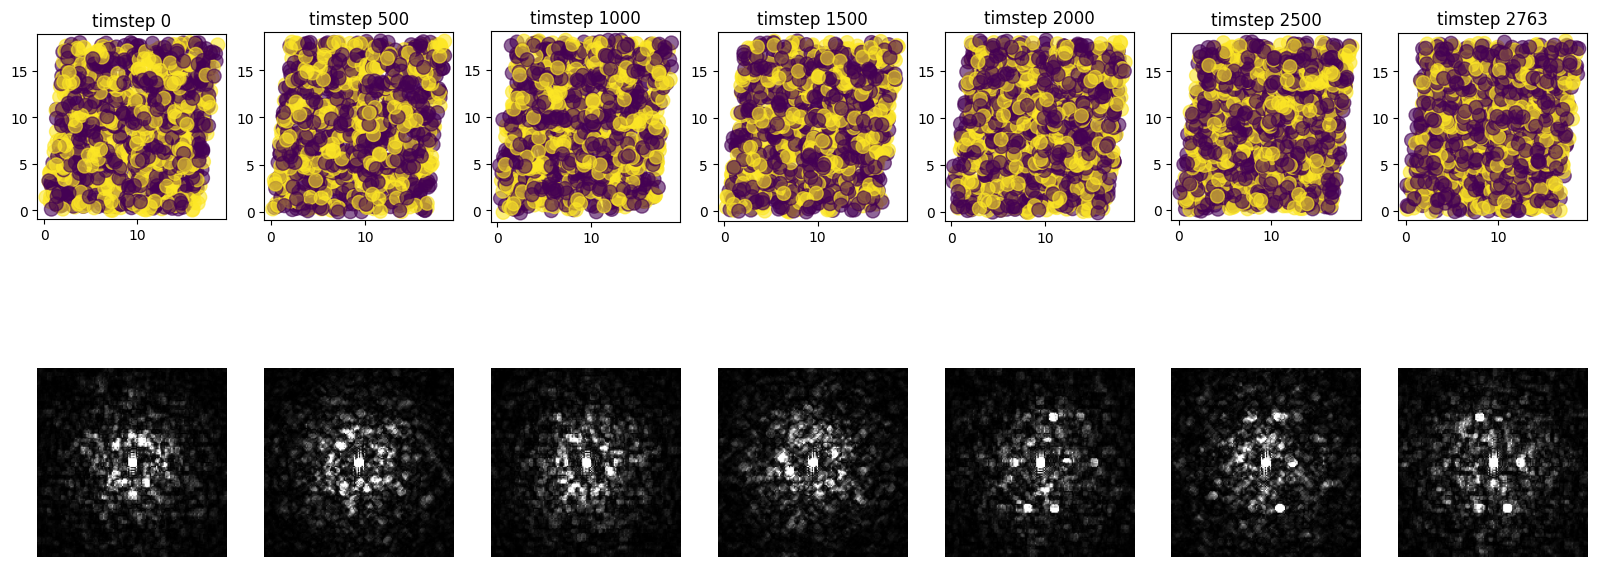

In [10]:
plt.close()
fig, axs = plt.subplots(2, 7, figsize=(20, 8))
for index, i in enumerate([0, 500, 1000, 1500, 2000, 2500, 2763]):    
    atoms, metadata, element = parse_xyz(f'/home/mnt/zwx/New_Bi2Se3_layered/ADHK_Bi2Se3.{i}', element_specified=False)
    # need to specify atoms. 1 is Bi and 2 is Se
    atoms[atoms[:, 0] == 1, 0] = 82 # Bi
    atoms[atoms[:, 0] == 2, 0] = 33 # Se
    poss = [[0,0]] # these are all in Angstroms, assuming center of the potential slice is at (0,0). if you don't specify poss, it will default to [[0,0]]. (single Cbed at the center)

    cbed_patterns, slices, test_rotated_coords, test_rotated_cells = overall_wrapper(atoms, metadata, zone_hkl = jnp.array([0,0,1]), theta = 0, pixel_size = 0.1, kirkland_jax=kirkland_jax
                                                                                    , poss = poss, threshold_A = 10 )
    for cbed_pattern in cbed_patterns.data_array:
        #fig, axs = plt.subplots(2,1, figsize=(4,9))
        array_center = [cbed_pattern.shape[0] // 2, cbed_pattern.shape[1] // 2]
        axs[0, index].scatter(atoms[:,1], atoms[:,2], c=atoms[:,0], cmap='viridis', s=100, alpha=0.6)
        axs[0, index].set_aspect('equal')
        axs[1, index].imshow(contrast_stretch(cbed_pattern[array_center[0]-75:array_center[0]+75, array_center[1]-75:array_center[1]+75],2,99), cmap='gray')
        axs[1, index].set_axis_off()
        axs[0, index].set_title(f'timstep {i}')

Time taken for preprocessing: 39.19919776916504 seconds
time taken for cbed calculation: 5.1020331382751465 seconds
Time taken for preprocessing: 36.4999885559082 seconds
time taken for cbed calculation: 5.4113030433654785 seconds


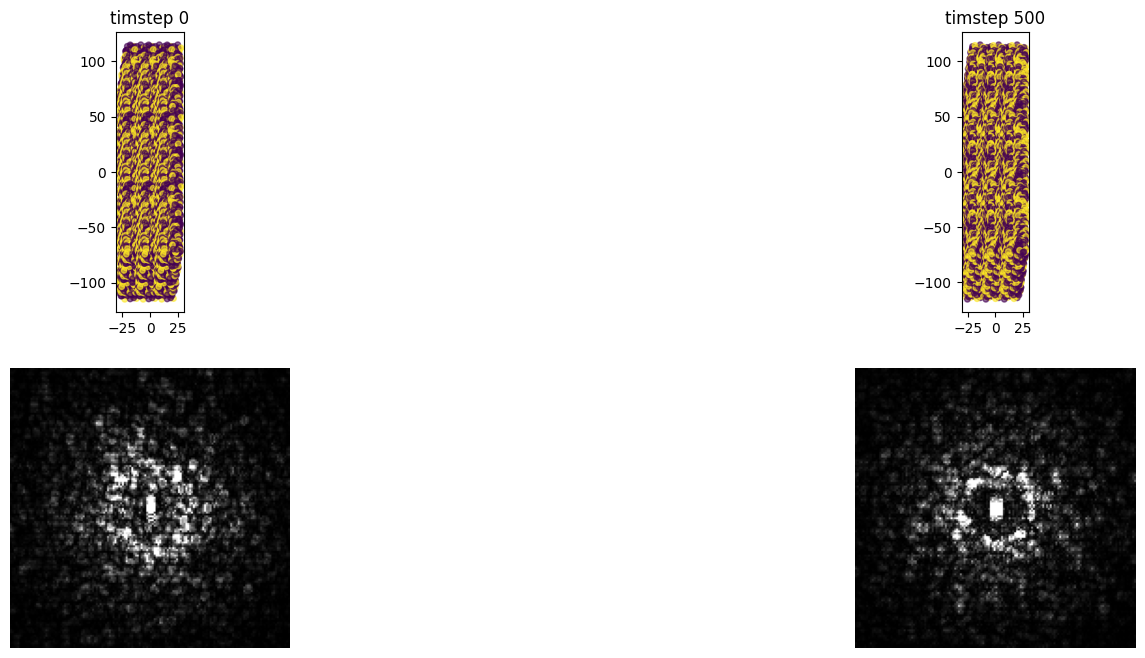

In [93]:
plt.close()
fig, axs = plt.subplots(2, 2, figsize=(20, 8))
for index, i in enumerate([0, 500]):    
    atoms, metadata, element = parse_xyz(f'/home/mnt/zwx/New_Bi2Se3_layered/ADHK_Bi2Se3.{i}', element_specified=False)
    # need to specify atoms. 1 is Bi and 2 is Se
    atoms[atoms[:, 0] == 1, 0] = 82 # Bi
    atoms[atoms[:, 0] == 2, 0] = 33 # Se
    poss = [[0,0]] # these are all in Angstroms, assuming center of the potential slice is at (0,0). if you don't specify poss, it will default to [[0,0]]. (single Cbed at the center)

    cbed_patterns, slices, test_rotated_coords, test_rotated_cells = overall_wrapper(atoms, metadata, zone_hkl = jnp.array([0,1,1]), theta = 0, pixel_size = 0.1, kirkland_jax=kirkland_jax, poss = poss, threshold_A = 5 )
    for cbed_pattern in cbed_patterns.data_array:
        #fig, axs = plt.subplots(2,1, figsize=(4,9))
        array_center = [cbed_pattern.shape[0] // 2, cbed_pattern.shape[1] // 2]
        axs[0, index].scatter(test_rotated_coords[:,1], test_rotated_coords[:,2], c=test_rotated_coords[:,0], cmap='viridis', s=16, alpha=0.6)
        axs[0, index].set_aspect('equal')
        axs[1, index].imshow(contrast_stretch(cbed_pattern[array_center[0]-75:array_center[0]+75, array_center[1]-75:array_center[1]+75],2,99), cmap='gray')
        axs[1, index].set_axis_off()
        axs[0, index].set_title(f'timstep {i}')

In [14]:
cbed_pattern.shape

(546, 546)

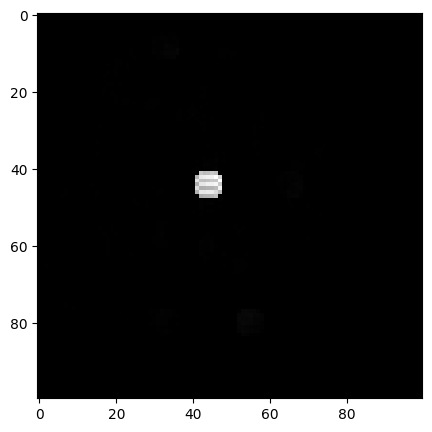

In [13]:
fig = plt.figure(figsize=(5,5))
plt.imshow(cbed_pattern[229:329, 229:329], cmap='gray')

In [ ]:
atoms_1800 = jnp.asarray(parse_xyz('Jul12_2025_Bi2Se3/Jul12_2025_Bi2Se3.1800', element_specified=False)[0], dtype=jnp.float32)
atoms_1800[atoms_1800[:, 0] == 1, 0] = 82 # Bi
atoms_1800[atoms_1800[:, 0] == 2, 0] = 33 # Se



array([[82.     ,  2.74205,  2.10698,  2.35506],
       [82.     ,  6.67029,  3.16614,  2.48363],
       [82.     ,  2.11199,  4.26303,  5.72901],
       ...,
       [33.     , 16.0491 , 11.0023 , 37.0122 ],
       [33.     , 14.5183 , 13.9884 , 40.1823 ],
       [82.     , 14.4982 , 16.2708 , 38.4504 ]], shape=(334, 4))

In [9]:
poss = [[0,0], [-5, 5], [5,5]] # these are all in Angstroms, assuming center of the potential slice is at (0,0). if you don't specify poss, it will default to [[0,0]]. (single Cbed at the center)

cbed_patterns, slices, test_rotated_coords, test_rotated_cells = overall_wrapper(atoms, metadata, zone_hkl = jnp.array([0,0,1]), theta = jnp.pi/4, pixel_size = 0.1, kirkland_jax=kirkland_jax, poss = poss )

Time taken for preprocessing: 6.411423683166504 seconds
time taken for cbed calculation: 1.8921546936035156 seconds


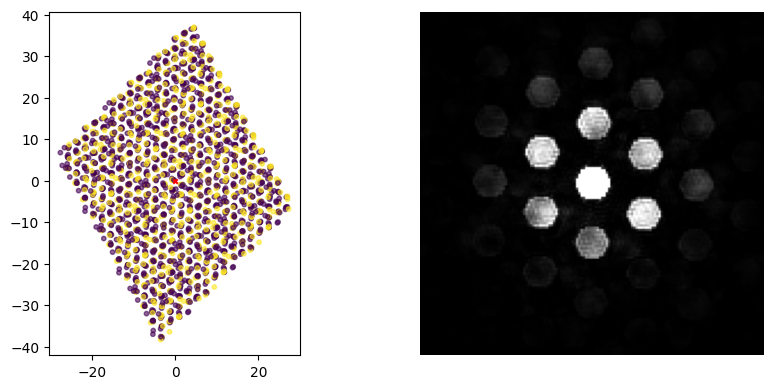

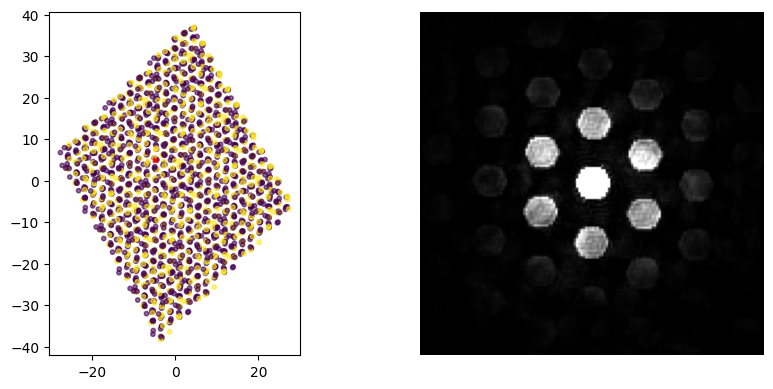

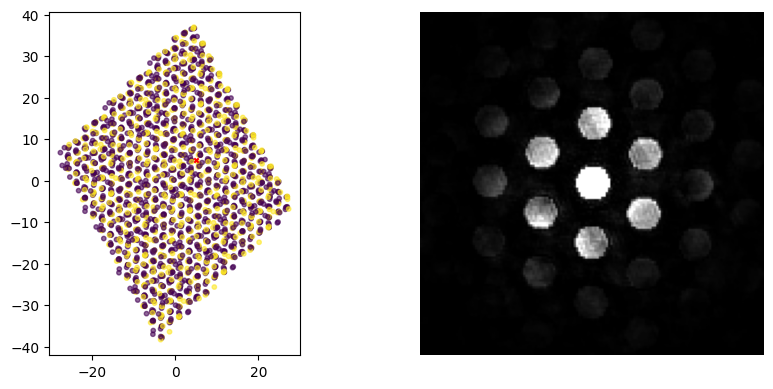

In [10]:
import matplotlib.pyplot as plt
for ci, cbed_pattern in enumerate(cbed_patterns.data_array):
    #print(cbed_pattern.data_array.shape)
    fig, axs = plt.subplots(1, 2, figsize=(9,4))
    array_center = [cbed_pattern.shape[0] // 2, cbed_pattern.shape[1] // 2]
    #axs[si,1].imshow(np.log10(cbed_pattern.data_array[array_center[0]-50:array_center[1]+50, array_center[0]-50:array_center[1]+50]), cmap='gray')
    #axs[si,1].imshow(cbed_pattern.data_array, cmap='gray')

    axs[0].scatter(test_rotated_coords[:,1], test_rotated_coords[:,2], c=test_rotated_coords[:,0], cmap='viridis', s=10, alpha=0.6)
    axs[0].set_aspect('equal')
    axs[0].scatter(poss[ci][0], poss[ci][1], c='red', s=10, marker='x', label='Probe Position')
    axs[1].imshow(contrast_stretch(cbed_pattern[array_center[0]-75:array_center[0]+75, array_center[1]-75:array_center[1]+75],2,99), cmap='gray')
    axs[1].set_axis_off()
    plt.tight_layout()

Time taken for preprocessing: 12.976742029190063 seconds
time taken for cbed calculation: 1.4214341640472412 seconds
Time taken for preprocessing: 12.525103092193604 seconds
time taken for cbed calculation: 3.1910438537597656 seconds


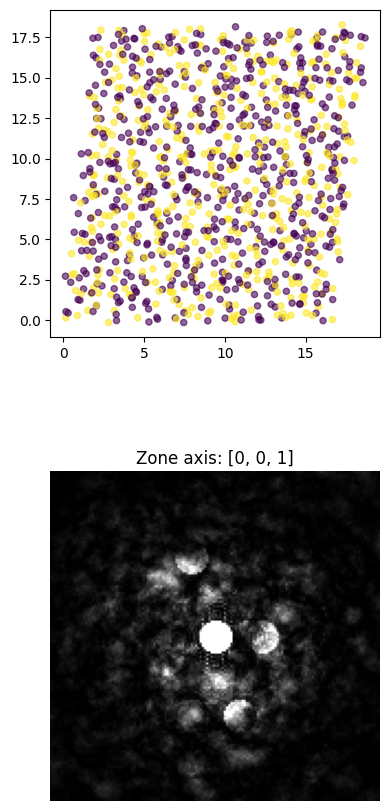

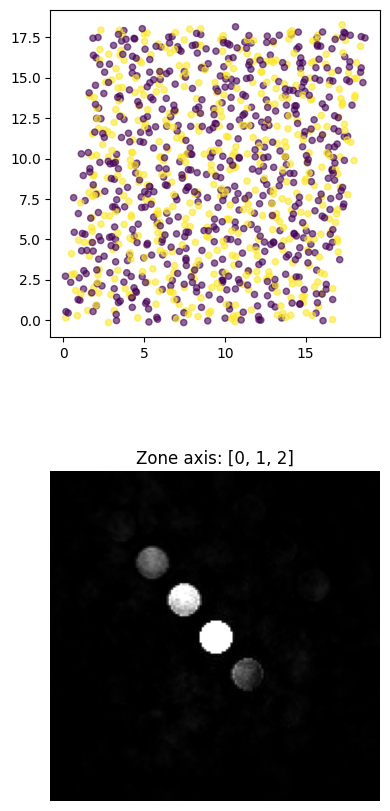

In [32]:
#for zone_hkl in [[0,0,1],[1,0,1],  [0,1,1], [1,1,1], [1, 0, 2], [0,1,2], [1,1,2]]:
all_test_rotated_coords = []
for zone_hkl in [[0,0,1],[0,1,2]]:
    cbed_patterns, slices, test_rotated_coords, test_rotated_cells = overall_wrapper(atoms, metadata, zone_hkl = jnp.array(zone_hkl), theta = 0, pixel_size = 0.1, kirkland_jax=kirkland_jax)
    for cbed_pattern in cbed_patterns.data_array:
        fig, axs = plt.subplots(2,1, figsize=(4,9))
        array_center = [cbed_pattern.shape[0] // 2, cbed_pattern.shape[1] // 2]
        axs[0].scatter(atoms[:,1], atoms[:,2], c=atoms[:,0], cmap='viridis', s=20, alpha=0.6)
        axs[0].set_aspect('equal')
        axs[1].imshow(contrast_stretch(cbed_pattern[array_center[0]-75:array_center[0]+75, array_center[1]-75:array_center[1]+75],2,99), cmap='gray')
        axs[1].set_axis_off()
        axs[1].set_title(f"Zone axis: {zone_hkl}")
        plt.tight_layout()
        all_test_rotated_coords.append(test_rotated_coords)

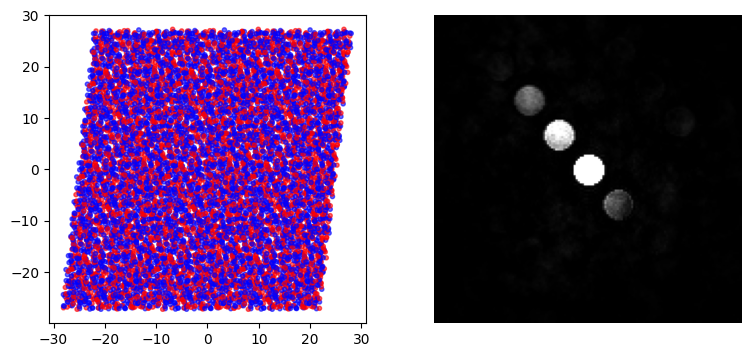

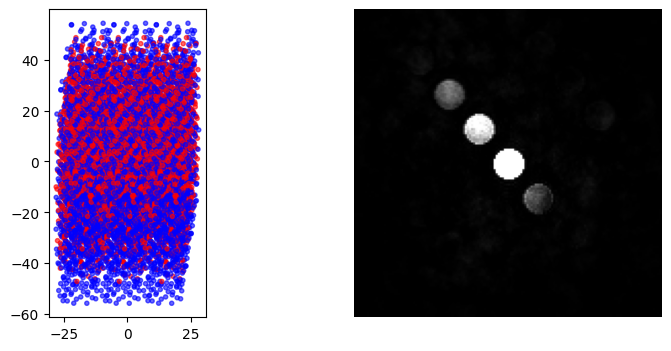

In [ ]:

colors = {82: 'red', 33: 'blue'}
for trci, test_rotated_coords in enumerate(all_test_rotated_coords:
    fig, axs = plt.subplots(1,2, figsize=(9,4))
    axs[0].scatter(test_rotated_coords[:,1], test_rotated_coords[:,2], c = [colors[int(t)] for t in test_rotated_coords[:,0]] , s=9, alpha=0.6)
    axs[0].set_aspect('equal')
    axs[1].imshow(contrast_stretch(cbed_patterns.data_array[0][array_center[0]-75:array_center[0]+75, array_center[1]-75:array_center[1]+75],2,99), cmap='gray')
    axs[1].set_axis_off()

In [10]:
from tqdm import tqdm
atoms, metadata, element = parse_xyz(f'/home/mnt/New_Bi2Se3_layered/ADHK_Bi2Se3.{1}', element_specified=False)
    # need to specify atoms. 1 is Bi and 2 is Se
atoms[atoms[:, 0] == 1, 0] = 82 # Bi
atoms[atoms[:, 0] == 2, 0] = 33 # Se
poss = [[0,0]] # these are all in Angstroms, assuming center of the potential slice is at (0,0). if you don't specify poss, it will default to [[0,0]]. (single Cbed at the center)

for zone_hkl in tqdm([[0,0,1],[0,1,2]]):
    cbed_patterns, slices, test_rotated_coords, test_rotated_cells = overall_wrapper(atoms, metadata, zone_hkl = jnp.array(zone_hkl), theta = 0, pixel_size = 0.1, kirkland_jax=kirkland_jax, poss = poss, threshold_A  = 5)
#    for cbed_pattern in cbed_patterns.data_array:
#        fig, axs = plt.subplots(2,1, figsize=(4,9))
#        array_center = [cbed_pattern.shape[0] // 2, cbed_pattern.shape[1] // 2]
#        axs[0].scatter(atoms[:,1], atoms[:,2], c=atoms[:,0], cmap='viridis', s=20, alpha=0.6)
#        axs[0].set_aspect('equal')
#        axs[1].imshow(contrast_stretch(cbed_pattern[array_center[0]-75:array_center[0]+75, array_center[1]-75:array_center[1]+75],2,99), cmap='gray')
#        axs[1].set_axis_off()
#        axs[1].set_title(f"Zone axis: {zone_hkl}")
#        plt.tight_layout()
#        all_test_rotated_coords.append(test_rotated_coords)


  0%|          | 0/2 [00:00<?, ?it/s]

Time taken for preprocessing: 24.700925827026367 seconds


 50%|█████     | 1/2 [00:28<00:28, 28.05s/it]

time taken for cbed calculation: 3.2847914695739746 seconds
Time taken for preprocessing: 24.345309495925903 seconds


100%|██████████| 2/2 [00:55<00:00, 27.58s/it]

time taken for cbed calculation: 2.7020673751831055 seconds


In [22]:
cbed_patterns.calib_x


Array([0.01792115], dtype=float64)

In [23]:
cbed_patterns.data_array.shape

(1, 558, 558)

In [ ]:
for cbed in cbed_patterns.data_array:
    plt.imshow(contrast_stretch(cbed,2,99), cmap='gray')
    plt.axis('off')
    plt.show()

In [11]:
import h5py
import numpy as np
def save_cbed_data(h5_filename, entries):
    """
    Save multiple CBED data entries to an HDF5 file.

    Parameters:
    - h5_filename: str, path to the output h5 file.
    - entries: list of dicts, each dict contains keys:
        - "cbed": np.ndarray (128x128)
        - "filename": str
        - "zone_axis": np.ndarray
        - "position": np.ndarray
        - "rotation": float
        - "crop": list or tuple or dict (any serializable info about cropping)
        - "scale": float
    """

    with h5py.File(h5_filename, "w") as f:
        for i, entry in enumerate(entries):
            group = f.create_group(f"entry_{i}")

            # Store cbed array
            group.create_dataset("cbed", data=entry["cbed"], dtype='float32')

            # Store strings as attributes (h5py needs strings encoded or use attrs)
            group.attrs["filename"] = entry["filename"]

            # Store arrays as datasets
            group.create_dataset("zone_axis", data=entry["zone_axis"])
            group.create_dataset("position", data=entry["position"])

            # Store scalar floats as attributes
            group.attrs["rotation"] = entry["rotation"]
            group.attrs["scale"] = entry["scale"]

            # Store crop info - if it's array-like, save as dataset; if complex, save as attribute string
            crop = entry["crop"]
            if isinstance(crop, (list, tuple, np.ndarray)):
                group.create_dataset("crop", data=crop)
            else:
                # Convert to string if needed
                group.attrs["crop"] = str(crop)

if __name__ == "__main__":
    # Example usage
    example_entry = {
        "cbed": np.random.rand(128, 128).astype(np.float32),
        "filename": "sample.xyz",
        "zone_axis": np.array([1, 0, 0]),
        "position": np.array([10.0, 5.0, 0.0]),
        "rotation": 45.0,
        "crop": [20, 20, 100, 100],  # example crop box (x_start, y_start, width, height)
        "scale": 12.5,
    }

    save_cbed_data("cbed_data.h5", [example_entry])

In [ ]:
cbed_patterns[0]

Array([[[7.33725738e-07, 1.32246383e-06, 2.47519774e-06, ...,
         2.29148050e-07, 1.06569393e-07, 1.16383061e-06],
        [7.96969740e-07, 1.13914721e-06, 2.03885368e-06, ...,
         6.19316243e-07, 5.40747208e-08, 1.14859681e-06],
        [2.22873296e-07, 3.00382278e-07, 3.04607889e-07, ...,
         2.57151803e-07, 2.16674912e-07, 7.07095947e-08],
        ...,
        [3.57731340e-07, 4.62148627e-08, 1.28892542e-07, ...,
         2.03502263e-08, 2.24960469e-07, 1.32682504e-06],
        [9.31971434e-08, 1.26456219e-07, 8.17405530e-08, ...,
         4.22796698e-08, 1.52318499e-07, 2.74715937e-07],
        [7.46009972e-07, 1.00086862e-06, 8.64652390e-07, ...,
         9.29189079e-08, 8.57434846e-08, 3.77250441e-08]],

       [[5.96790087e-08, 3.19803395e-07, 4.67594472e-08, ...,
         2.17888008e-07, 3.40485471e-07, 9.22187574e-08],
        [1.26533442e-07, 3.04867771e-08, 5.27549724e-08, ...,
         1.10905982e-07, 1.61792930e-07, 1.74560648e-07],
        [1.64926951e-08, 

In [ ]:
h5_filename = '/home/mnt/cbed_data_test.h5'
filenames  = [f'/home/mnt/New_Bi2Se3_layered/ADHK_Bi2Se3.{i}' for i in [2500, 2600]]
zone_axes = [jnp.array([0,0,1]), jnp.array([0,1,2])]
positions = jnp.array([[0,0]]) # these are all in Angstroms, assuming center of the potential slice is at (0,0). if you don't specify poss, it will default to [[0,0]]. (single Cbed at the center)
entries = []
cbeds = []
for fi, filename in tqdm(enumerate(filenames)):
    atoms, metadata, element = parse_xyz(filename, element_specified=False)
    atoms[atoms[:, 0] == 1, 0] = 82 # Bi
    atoms[atoms[:, 0] == 2, 0] = 33 # Se
    for zone_axis in zone_axes:
        for pos in positions:
            for rot in np.random.uniform(0, 2 * jnp.pi, 2):  # Random rotation

                cbed_patterns, slices, test_rotated_coords, test_rotated_cells = overall_wrapper(atoms, metadata, zone_hkl = zone_axis, theta = rot, pixel_size = 0.1, kirkland_jax=kirkland_jax, poss = jnp.array([pos]), threshold_A = 20)
                cbed = np.array(cbed_patterns.data_array[0]) # Assuming you want the first pattern
                cbed_center = np.array([cbed.shape[0] // 2, cbed.shape[1] // 2])
                crop_shift = np.random.randint(-5, 5, size=2)  # Random crop shiftm   
                crop_size = 128
                cbed_cropped = cbed[cbed_center[0]-crop_size//2 + crop_shift[0]:cbed_center[0]+crop_size//2 + crop_shift[0],
                                    cbed_center[1]-crop_size//2 + crop_shift[1]:cbed_center[1]+crop_size//2 + crop_shift[1]]
                scale = np.array([cbed_patterns.calib_x, cbed_patterns.calib_y])
                entry = {
                    "cbed": cbed_cropped.astype(np.float16),
                    "filename": filename,
                    "zone_axis": np.array(zone_axis),
                    "position": np.array(pos),
                    "rotation": rot,  # Store only one rotation angle for simplicity
                    "crop": [int(crop_shift[0]), int(crop_shift[1]), crop_size, crop_size],  # example crop box (x_start, y_start, width, height)
                    "scale": scale
                }
                entries.append(entry)
                cbeds.append(cbed)

save_cbed_data(h5_filename, entries)

        
        

0it [00:00, ?it/s]

Time taken for preprocessing: 11.117291450500488 seconds
time taken for cbed calculation: 3.620457172393799 seconds
Time taken for preprocessing: 11.507633924484253 seconds
time taken for cbed calculation: 3.17785382270813 seconds
Time taken for preprocessing: 11.512163877487183 seconds
time taken for cbed calculation: 4.062435865402222 seconds
Time taken for preprocessing: 12.429172992706299 seconds
time taken for cbed calculation: 8.206271409988403 seconds


1it [01:06, 66.30s/it]

Time taken for preprocessing: 11.8473641872406 seconds
time taken for cbed calculation: 4.213853359222412 seconds
Time taken for preprocessing: 10.705469369888306 seconds
time taken for cbed calculation: 3.842733144760132 seconds
Time taken for preprocessing: 12.298655033111572 seconds
time taken for cbed calculation: 8.776079893112183 seconds
Time taken for preprocessing: 11.594447374343872 seconds


2it [02:14, 67.26s/it]

time taken for cbed calculation: 4.316709280014038 seconds


In [20]:
cbeds = []
with open('/home/mnt/cbed_data_test.h5', 'rb') as f:
    with h5py.File(f, 'r') as h5_file:
        for key in h5_file.keys():
            print(f"Key: {key}")
            group = h5_file[key]
            print(f"  Filename: {group.attrs['filename']}")
            print(f"  Zone Axis: {group['zone_axis'][:]}")
            print(f"  Position: {group['position'][:]}")
            print(f"  Rotation: {group.attrs['rotation']}")
            print(f"  Crop: {group['crop'][:]}")
            print(f"  Scale: {group.attrs['scale']}")
            cbeds.append(group['cbed'][:])

Key: entry_0
  Filename: /home/mnt/New_Bi2Se3_layered/ADHK_Bi2Se3.2500
  Zone Axis: [0 0 1]
  Position: [0 0]
  Rotation: 4.360703933706059
  Crop: [ -2   1 128 128]
  Scale: [[0.01540832]
 [0.01540832]]
Key: entry_1
  Filename: /home/mnt/New_Bi2Se3_layered/ADHK_Bi2Se3.2500
  Zone Axis: [0 0 1]
  Position: [0 0]
  Rotation: 5.728715428190269
  Crop: [  1  -1 128 128]
  Scale: [[0.01470588]
 [0.01470588]]
Key: entry_2
  Filename: /home/mnt/New_Bi2Se3_layered/ADHK_Bi2Se3.2500
  Zone Axis: [0 1 2]
  Position: [0 0]
  Rotation: 1.4608905044852525
  Crop: [ -5  -2 128 128]
  Scale: [[0.01506024]
 [0.01506024]]
Key: entry_3
  Filename: /home/mnt/New_Bi2Se3_layered/ADHK_Bi2Se3.2500
  Zone Axis: [0 1 2]
  Position: [0 0]
  Rotation: 1.0111105430303764
  Crop: [  4   1 128 128]
  Scale: [[0.00961538]
 [0.00961538]]
Key: entry_4
  Filename: /home/mnt/New_Bi2Se3_layered/ADHK_Bi2Se3.2600
  Zone Axis: [0 0 1]
  Position: [0 0]
  Rotation: 4.270540191777874
  Crop: [ -1   2 128 128]
  Scale: [[0.014

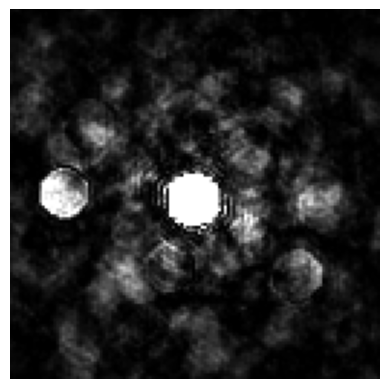

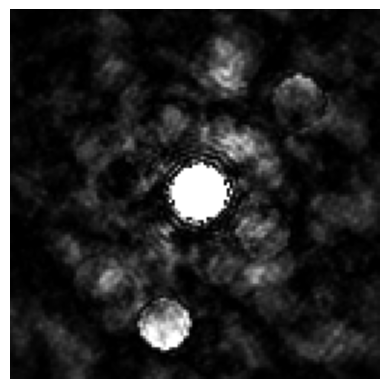

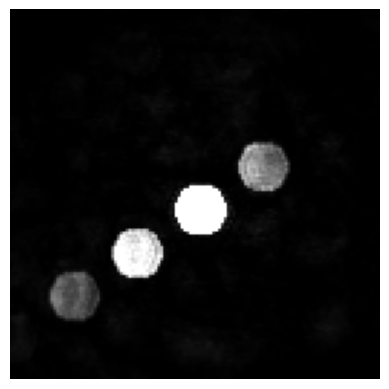

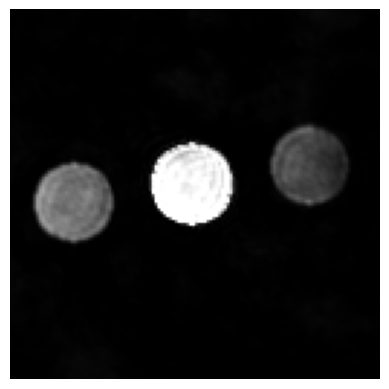

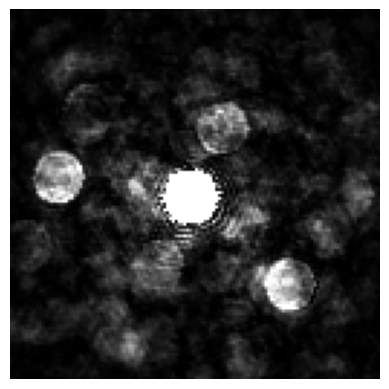

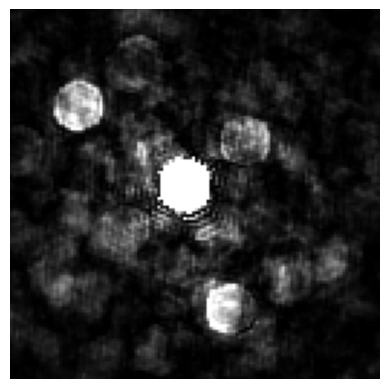

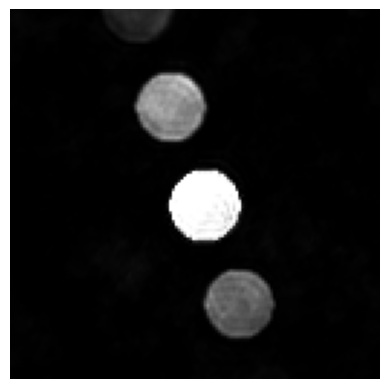

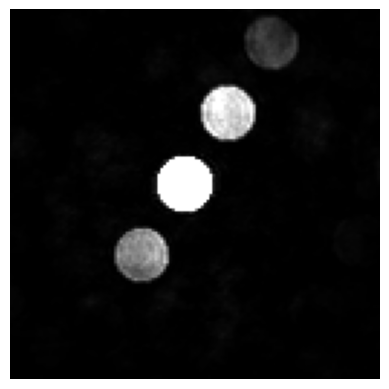

In [22]:
for cbed in cbeds:
    plt.imshow(contrast_stretch(cbed,2,98), cmap='gray')
    plt.axis('off')
    plt.show()

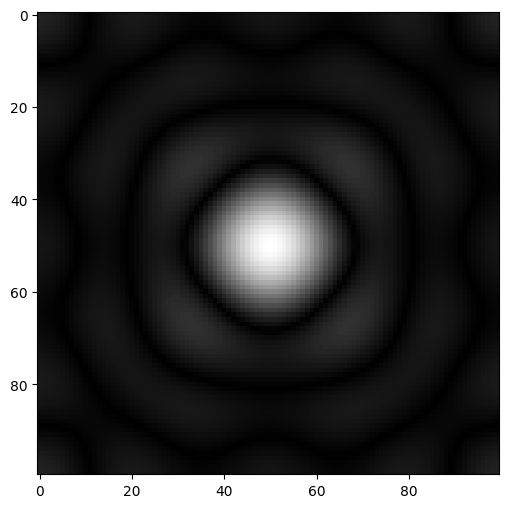

In [44]:
from ptyrodactyl.electrons import make_probe
probe = make_probe(aperture=2.5,
                   voltage = 100,
                   defocus = 0.0,
                   image_size = jnp.array([100, 100]),
                   calibration_pm = 5000/100,
                   #defocus = -0.0,
                   #c3=0.0,
                   #c5=0.0

                   )
fig = plt.figure(figsize=(6,6))
plt.imshow(jnp.abs(probe), cmap='gray')



In [40]:
probe

Array([[0.0001+0.j, 0.0001+0.j, 0.0001+0.j, ..., 0.0001+0.j, 0.0001+0.j,
        0.0001+0.j],
       [0.0001+0.j, 0.0001+0.j, 0.0001+0.j, ..., 0.0001+0.j, 0.0001+0.j,
        0.0001+0.j],
       [0.0001+0.j, 0.0001+0.j, 0.0001+0.j, ..., 0.0001+0.j, 0.0001+0.j,
        0.0001+0.j],
       ...,
       [0.0001+0.j, 0.0001+0.j, 0.0001+0.j, ..., 0.0001+0.j, 0.0001+0.j,
        0.0001+0.j],
       [0.0001+0.j, 0.0001+0.j, 0.0001+0.j, ..., 0.0001+0.j, 0.0001+0.j,
        0.0001+0.j],
       [0.0001+0.j, 0.0001+0.j, 0.0001+0.j, ..., 0.0001+0.j, 0.0001+0.j,
        0.0001+0.j]], dtype=complex128)